# Homework — Customer Segmentation with Wholesale Customers

## Brief

Bạn là analyst cho một nhà phân phối thực phẩm. Hãy dùng dữ liệu **Wholesale Customers** để trả lời một câu hỏi thực tế:

> Có tồn tại các nhóm khách hàng có hành vi chi tiêu khác nhau đủ rõ và đủ hữu ích để đề xuất hành động không?

Dữ liệu có 440 khách hàng và 6 nhóm chi tiêu hằng năm: `Fresh`, `Milk`, `Grocery`, `Frozen`, `Detergents_Paper`, `Delicassen`.

Đây là **notebook làm việc của bạn**, không phải chuỗi bước cần làm lại. Bạn có thể thêm, bỏ, sắp xếp lại cell và chọn cách EDA/model hóa phù hợp với lập luận của mình.

## Yêu cầu đầu ra

Nộp một báo cáo notebook có thể giúp người khác ra quyết định. Bài làm cần có:

- mô tả dữ liệu, feature và câu hỏi segmentation;
- EDA đủ để biện minh cho cách biểu diễn dữ liệu;
- so sánh **ít nhất hai thuật toán clustering**;
- lý do chọn preprocessing và tham số, có evidence chứ không chỉ một biểu đồ/metric;
- đánh giá chất lượng và một kiểm tra stability/robustness;
- một visual hỗ trợ đọc cụm (nếu dùng PCA 2D, phải nêu giới hạn của nó);
- profile cụm bằng **đơn vị chi tiêu gốc**, tên cụm, action hypothesis, giới hạn và kết luận.

Không có yêu cầu về số lượng biểu đồ, thứ tự section hay thư viện. Chất lượng lập luận quan trọng hơn số cell/code.

## Quy ước và lưu ý

- Sáu cột chi tiêu là input mặc định cho clustering.
- `Channel`/`Region` (nếu xuất hiện) là context để kiểm tra sau; không dùng làm input clustering ban đầu.
- Giữ một bản dữ liệu gốc để profile/diễn giải. Data đã scale chỉ nên phục vụ model.
- Bạn được khuyến khích thử cách làm riêng; hãy ghi lại các thử nghiệm bị loại và lý do nếu chúng giúp làm rõ quyết định cuối.

Nộp `.ipynb` đã chạy đầy đủ. Tên file: `HW_clustering_<student_id>.ipynb`.

In [18]:
!pip install numpy pandas matplotlib scikit-learn scipy ucimlrepo

In [19]:
# Nếu môi trường thiếu thư viện, bỏ comment và chạy một lần:
# %pip install numpy pandas matplotlib scikit-learn scipy ucimlrepo

from pathlib import Path

import numpy as np
import pandas as pd
import matplotlib.pyplot as plt

from sklearn.cluster import AgglomerativeClustering, DBSCAN, KMeans
from sklearn.decomposition import PCA
from sklearn.metrics import adjusted_rand_score, davies_bouldin_score, silhouette_score
from sklearn.preprocessing import MinMaxScaler, RobustScaler, StandardScaler

plt.style.use('seaborn-v0_8-whitegrid')
pd.set_option('display.float_format', lambda value: f'{value:,.2f}')
RANDOM_STATE = 42


In [20]:
import seaborn as sns

# Dữ liệu

Cell này chỉ nạp dữ liệu và tách phần chi tiêu. Từ đây, bạn tự xây dựng analysis workspace của mình.

In [21]:
SPENDING_FEATURES = [
    'Fresh', 'Milk', 'Grocery', 'Frozen', 'Detergents_Paper', 'Delicassen'
]

candidate_paths = [
    Path('data/wholesale_customers.csv'),
    Path('../data/wholesale_customers.csv'),
    Path('../../data/wholesale_customers.csv'),
]
data_path = next((path for path in candidate_paths if path.exists()), None)

if data_path is not None:
    df = pd.read_csv(data_path)
    source = str(data_path)
else:
    try:
        from ucimlrepo import fetch_ucirepo
        dataset = fetch_ucirepo(id=292)
        df = dataset.data.features.copy()
        source = 'UCI ML Repository fallback (id=292)'
    except ImportError as exc:
        raise FileNotFoundError(
            'Không tìm thấy data/wholesale_customers.csv. '
            'Hãy đặt file đúng đường dẫn hoặc cài ucimlrepo để dùng fallback.'
        ) from exc

missing = sorted(set(SPENDING_FEATURES) - set(df.columns))
if missing:
    raise ValueError(f'File thiếu cột chi tiêu: {missing}')

X_raw = df[SPENDING_FEATURES].copy()
print(f'Nguồn: {source}')
print(f'Dữ liệu đầy đủ: {df.shape[0]} dòng × {df.shape[1]} cột')
print(f'Matrix chi tiêu: {X_raw.shape[0]} dòng × {X_raw.shape[1]} features')
display(df.head())


Nguồn: UCI ML Repository fallback (id=292)
Dữ liệu đầy đủ: 440 dòng × 7 cột
Matrix chi tiêu: 440 dòng × 6 features


,Channel,Fresh,Milk,Grocery,Frozen,Detergents_Paper,Delicassen
0,2,12669,9656,7561,214,2674,1338
1,2,7057,9810,9568,1762,3293,1776
2,2,6353,8808,7684,2405,3516,7844
3,1,13265,1196,4221,6404,507,1788
4,2,22615,5410,7198,3915,1777,5185


# TODO A — Framing và audit dữ liệu

Hãy thêm cell/cell Markdown của bạn để trả lời:

- Một dòng dữ liệu đại diện cho điều gì? Những feature nào có ý nghĩa cho bài toán segmentation?
- Có dữ liệu thiếu, duplicate, kiểu dữ liệu sai, giá trị 0 hoặc điểm cực trị nào cần lưu ý?
- `Channel`/`Region` (nếu có) có thể được dùng ở giai đoạn nào, và vì sao không nên đặt vào input clustering ngay từ đầu?
- Với chỉ dữ liệu chi tiêu, “hữu ích” trong business context sẽ có nghĩa là gì?

Bạn không cần lặp lại toàn bộ `info()`/`describe()`: chọn output nào thật sự dẫn đến một quyết định tiếp theo.

## TODO A — Framing and Data Audit

### 1. What does a data row represent? Which features are significant for the segmentation task?
-   **Data Row Representation:** Each row represents the sum of a customer's annual purchases for various product categories.
-   **Significant Features for Segmentation:** All spending columns (`Fresh`, `Milk`, `Grocery`, `Frozen`, `Detergents_Paper`, `Delicassen`) are significant. They directly reflect customer shopping behavior, and the primary goal is to group customers with similar spending patterns.

### 2. Are there any missing data, duplicates, incorrect data types, zero values, or outliers to note?
-   **Missing Data:** None were found in `X_raw` (all columns have 440 non-null entries).
-   **Data Types:** All spending columns are of `int64` type, which is appropriate for numerical spending data.
-   **Zero Values:** These are expected as customers may not purchase every product type annually. However, they may require specific handling during data transformations (e.g., `log`).
-   **Outliers:** Significant differences between the mean and maximum values for all spending features (especially `Fresh`, `Milk`, `Grocery`) indicate a right-skewed distribution and the presence of outliers. These can considerably impact distance-based clustering algorithms (e.g., K-Means).

### 3. At what stage can `Channel`/`Region` (if available) be used, and why should they not be included in the initial clustering input?
-   **Usage Stage:** `Channel` and `Region` (if present) should be utilized *after* initial clustering. They can aid in profiling and interpreting the formed clusters (e.g., to identify if a high-spending cluster is concentrated in a specific sales channel or geographic region).
-   **Reason for Exclusion from Initial Input:** Including `Channel` and `Region` in the initial clustering input might cause clusters to form predominantly based on these contextual factors rather than underlying spending behavior. This could obscure the discovery of subtle customer behavioral groups independent of external attributes.

### 4. With only spending data, what would "useful" mean in a business context?
-   **"Useful" in a Business Context:** For segmentation based solely on spending data, a segmentation is considered useful if it demonstrates:
    -   **Clear Differentiation:** Customer groups exhibit distinctly different and interpretable spending patterns.
    -   **Actionability:** Each group can be targeted with tailored marketing strategies, promotions, or product offerings.
    -   **Stability:** Customer groups remain relatively consistent over time and across different model runs.
    -   **Value:** Targeting these groups yields significant business benefits (e.g., increased revenue, improved customer retention).
    -   **Interpretability:** The segmentation is easily understood and explained to non-technical stakeholders for informed decision-making.

In [22]:
# Analysis workspace — thêm cell EDA của bạn bên dưới hoặc thay cell này.
# Gợi ý khởi đầu (không bắt buộc):
# display(X_raw.describe().T)

print('Distribution of Data')
display(X_raw.describe().T)
print('\n')
print('Check type and Null value of Data:')
X_raw.info()

Distribution of Data


,count,mean,std,min,25%,50%,75%,max
Fresh,440.00,"12,000.30","12,647.33",3.00,"3,127.75","8,504.00","16,933.75","112,151.00"
Milk,440.00,"5,796.27","7,380.38",55.00,"1,533.00","3,627.00","7,190.25","73,498.00"
Grocery,440.00,"7,951.28","9,503.16",3.00,"2,153.00","4,755.50","10,655.75","92,780.00"
Frozen,440.00,"3,071.93","4,854.67",25.00,742.25,"1,526.00","3,554.25","60,869.00"
Detergents_Paper,440.00,"2,881.49","4,767.85",3.00,256.75,816.50,"3,922.00","40,827.00"
Delicassen,440.00,"1,524.87","2,820.11",3.00,408.25,965.50,"1,820.25","47,943.00"




Check type and Null value of Data:
<class 'pandas.core.frame.DataFrame'>
RangeIndex: 440 entries, 0 to 439
Data columns (total 6 columns):
 #   Column            Non-Null Count  Dtype
---  ------            --------------  -----
 0   Fresh             440 non-null    int64
 1   Milk              440 non-null    int64
 2   Grocery           440 non-null    int64
 3   Frozen            440 non-null    int64
 4   Detergents_Paper  440 non-null    int64
 5   Delicassen        440 non-null    int64
dtypes: int64(6)
memory usage: 20.8 KB


# TODO B — EDA tự do, nhưng có chủ đích

Tự chọn visual và phép tóm tắt phù hợp. EDA của bạn cần làm rõ các câu hỏi sau:

- Phân phối/độ lệch/outlier nào sẽ ảnh hưởng cách tính khoảng cách?
- Feature nào có thang đo hoặc mức biến thiên khác đáng kể?
- Có quan hệ giữa các nhóm chi tiêu nào đáng để chú ý khi đọc cluster profile?
- Những quan sát này dẫn bạn đến thử preprocessing hoặc model nào?

Gắn một đoạn nhận xét ngắn dưới mỗi visual quan trọng. Không cần vẽ mọi loại biểu đồ nếu chúng không giúp trả lời câu hỏi.

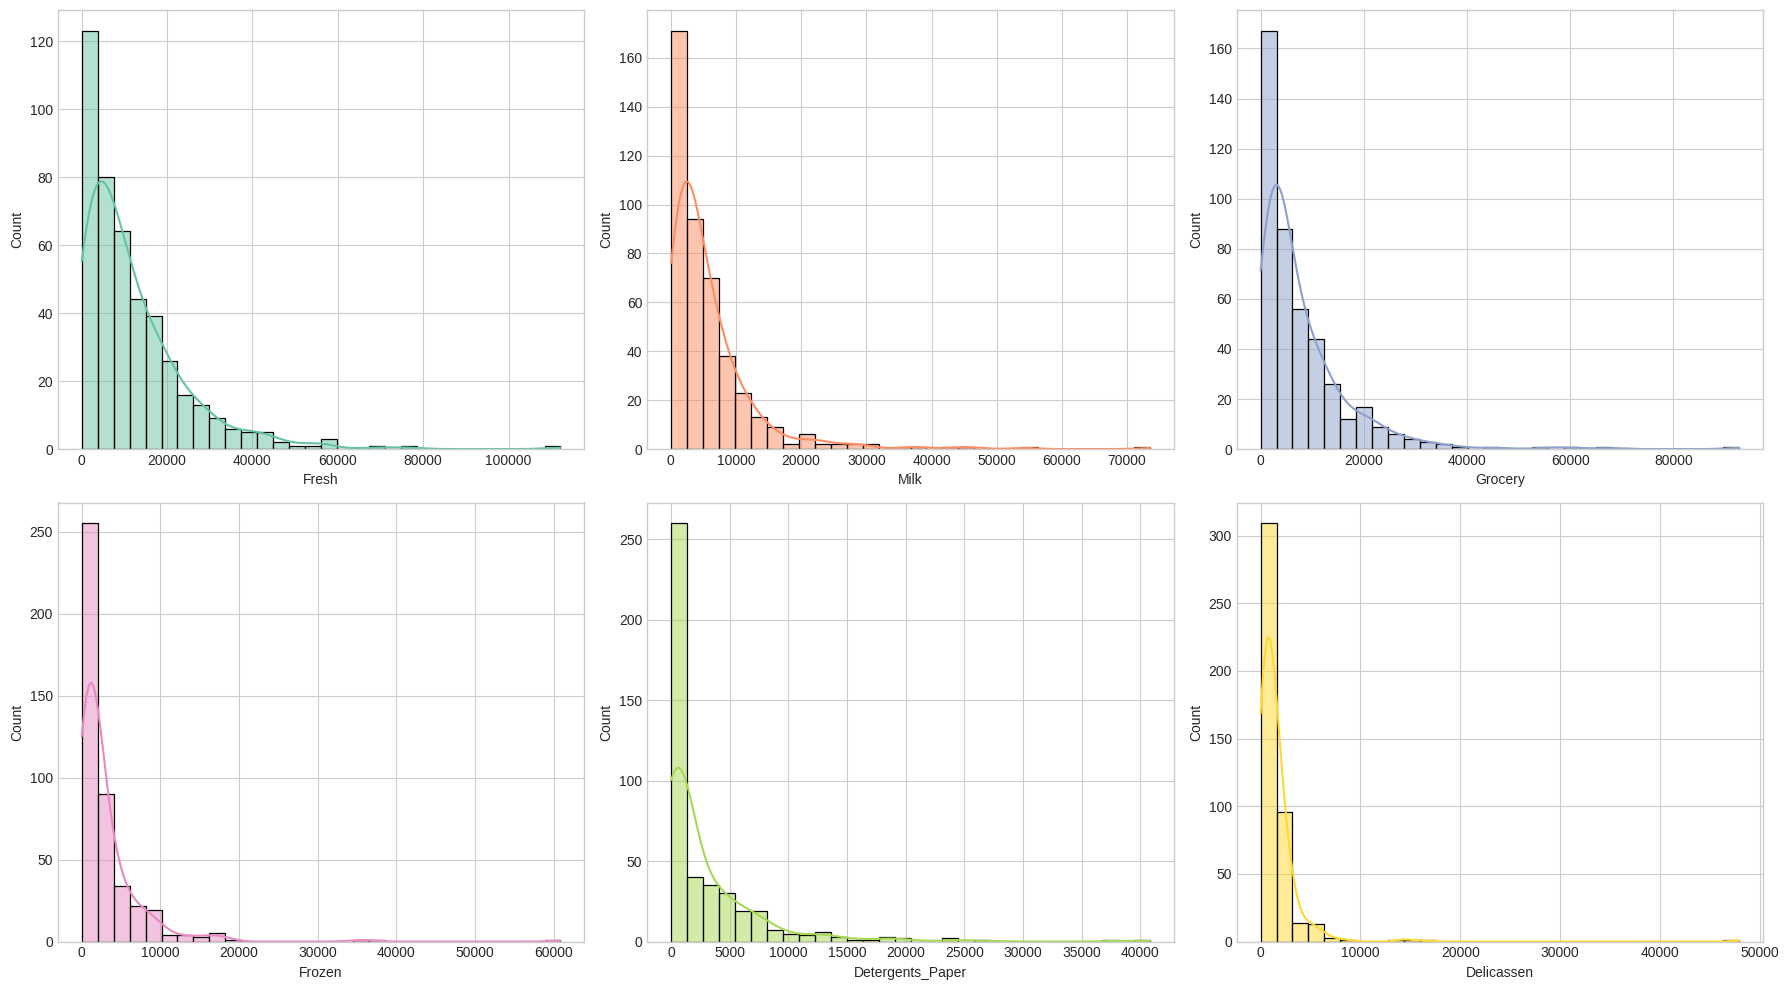

In [23]:
colors = sns.color_palette(palette='Set2')

num_features = len(SPENDING_FEATURES)
nrows = int(np.ceil(np.sqrt(num_features)))
ncols = int(np.ceil(num_features / nrows))

fig, axes = plt.subplots(ncols, nrows, figsize=(18, 10))
axes = axes.flatten()

for i, feature in enumerate(SPENDING_FEATURES):
  sns.histplot(
      data=X_raw,
      x=feature,
      bins=30,
      kde=True,
      ax=axes[i],
      color=colors[i]
  )
plt.tight_layout()
plt.show()

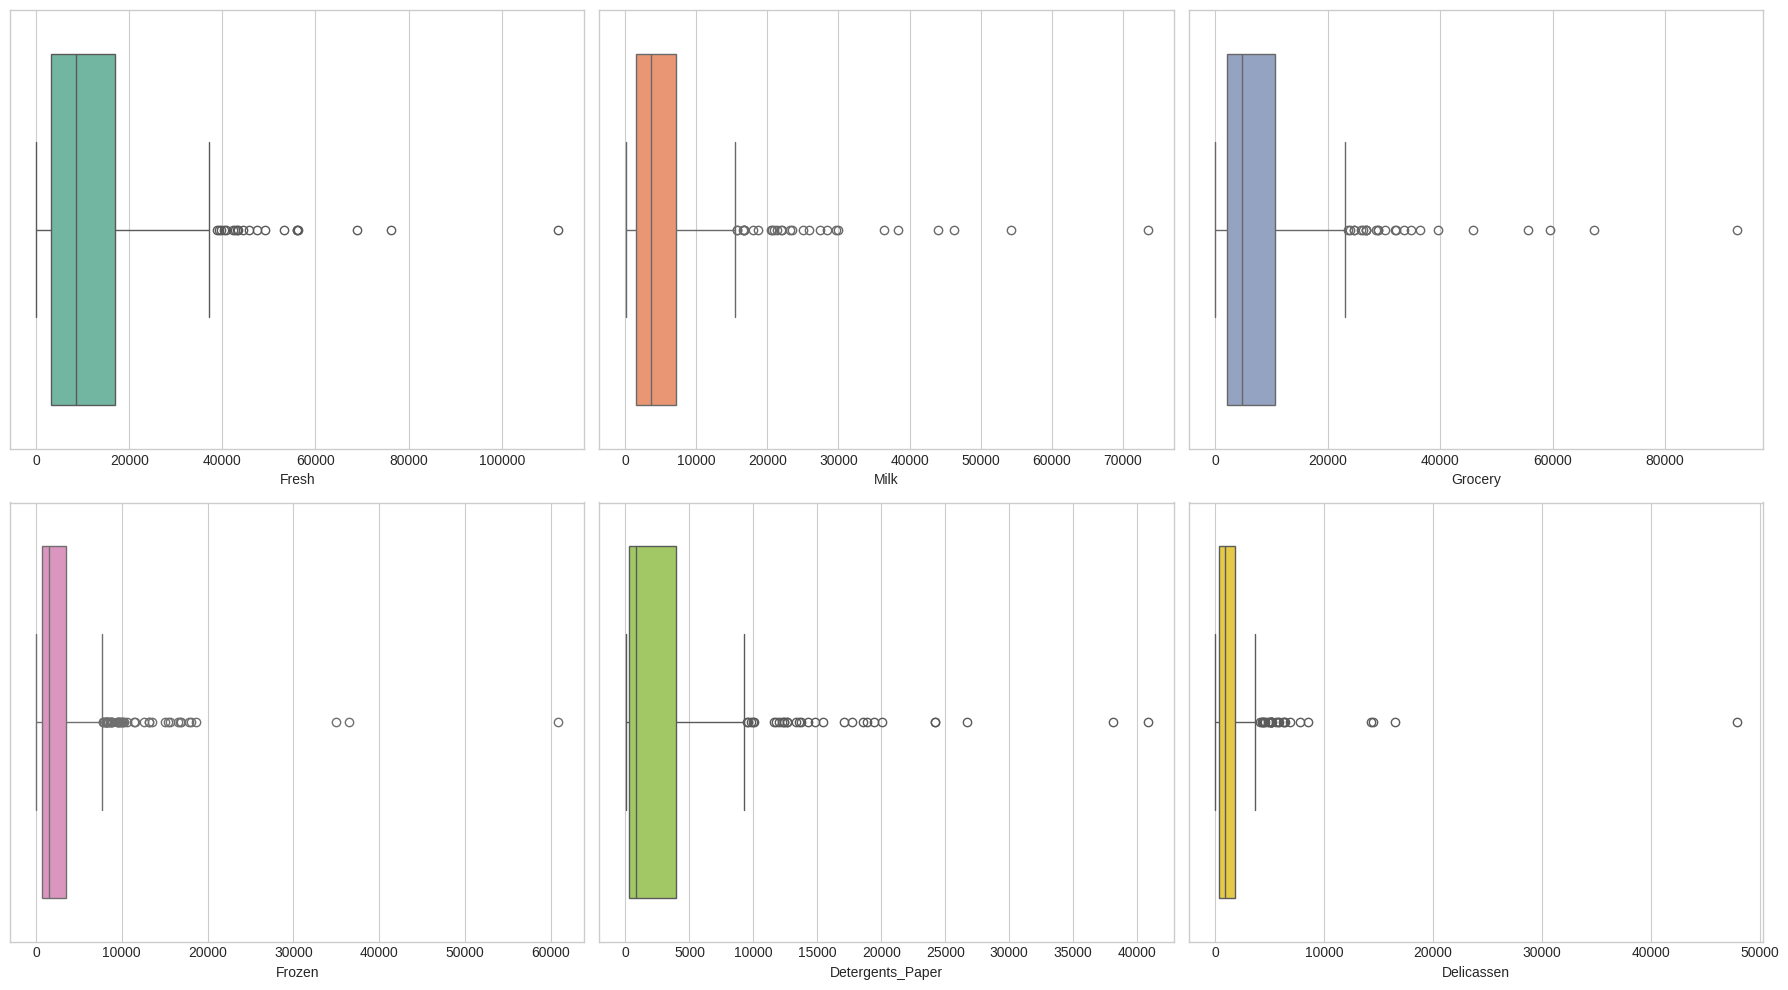

In [24]:
fig, axes = plt.subplots(ncols, nrows, figsize=(18, 10))
axes = axes.flatten()

for i, feature in enumerate(SPENDING_FEATURES):
  sns.boxplot(
      data=X_raw,
      x=feature,
      ax=axes[i],
      color = colors[i]
  )

plt.tight_layout()
plt.show()

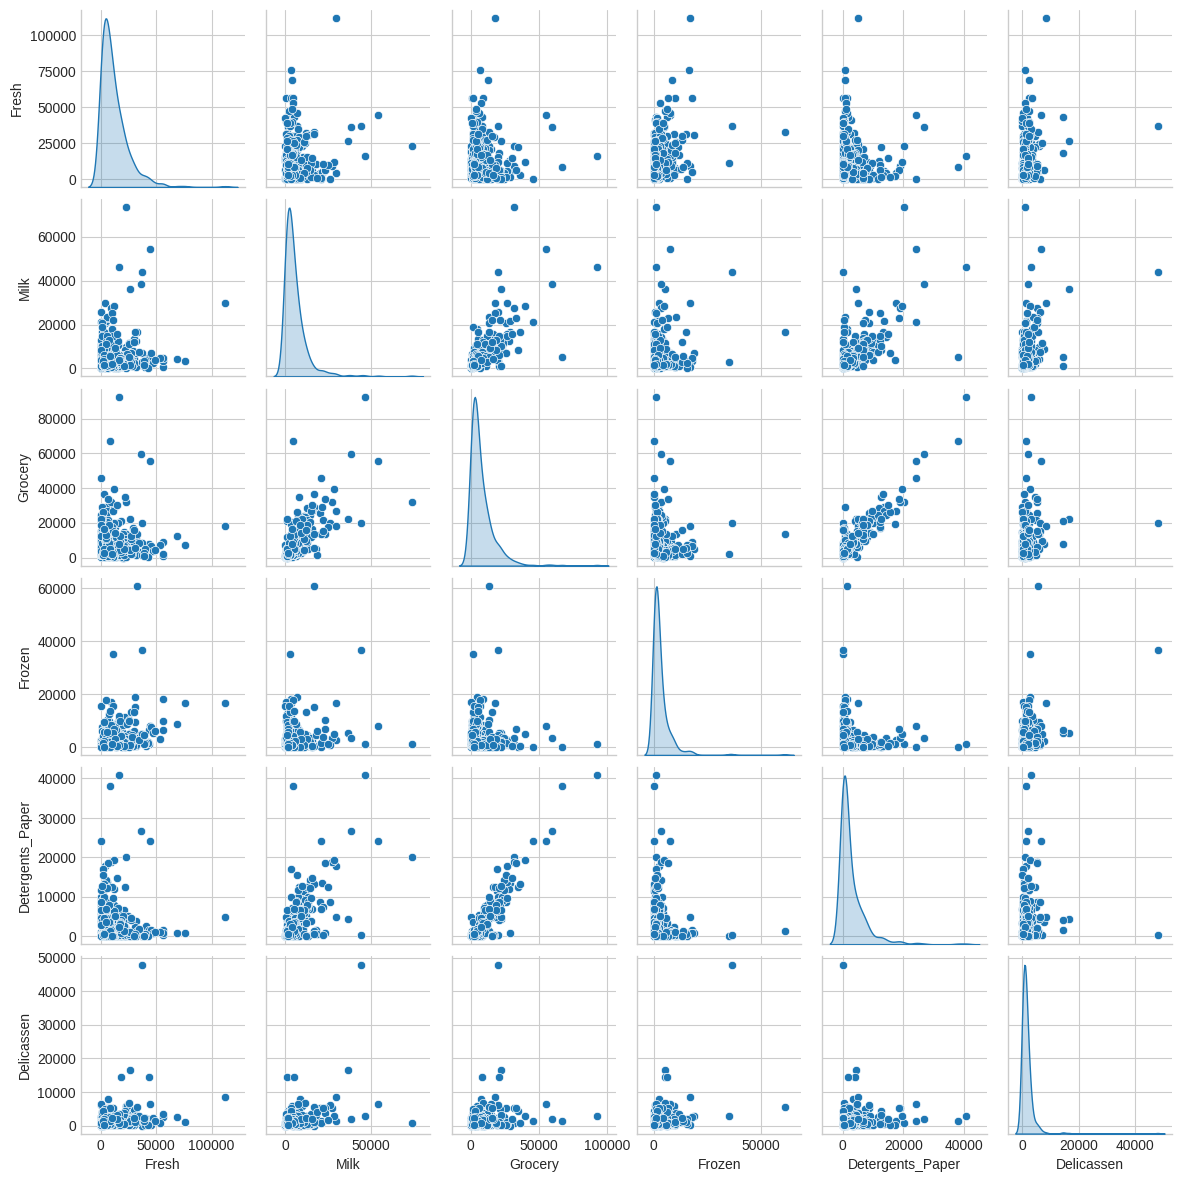

In [25]:
sns.pairplot(data=X_raw, diag_kind='kde', height=2, aspect=1)
plt.show()

1. How do distribution/skewness/outliers affect distance calculations?

**Skewness**: All spending features exhibit a strong right-skewed distribution.
This means that a large number of customer have low spending, while a smaller number of customer have a very high speding in theses categories.

This is clearly shown in the histograms: long tail to the right and boxplot: median closer to the bottom, with a long upper whisker.

**Outlier**: These outliers represent customers with exceptionally high annual spending compared to the majority.

The presence of outliers can significantly influence distance-based clustering algorithms (K-Means, Agglomerative clustering).

2. Which features have significantly different scales or variances?

There are substantial differences in the scales of spending across categories. For instance`Fresh`, `Grocery` tend to have much higher maximum spending values than `Frozen` and `Delicassen`.

3. Which relationships between spending groups are worth noting when reading cluster profiles?

The pairplot shows potential linear relationships between some pairs of features

Positive correlation: `Milk` - `Grocery`, `Milk` - `Detergents_Paper`
This implies that customers who buy a lot of milk also tent to buy a lot of grocery and detergents_paper product


#### What observations lead you to try which preprocessing or models?

These observations lead to the following preprocessing and model decisions:

1.  **Logarithmic Transformation:** To reduce strong skewness and mitigate the impact of outliers, a logarithmic transformation (e.g., `np.log1p`) would be very beneficial. This helps bring the data closer to a normal distribution, improving the performance of many clustering algorithms.
2.  **Scaling:** Due to the scale differences between features, a scaling technique must be applied after logarithmic transformation. `StandardScaler` or `RobustScaler` are good candidates to ensure that each feature contributes equally to the distance metrics used in clustering, preventing features with larger values from disproportionately influencing the clusters.
3.  **Clustering Algorithms:** With transformed and scaled data, distance-based clustering algorithms such as **K-Means** and **Agglomerative Clustering** would be suitable choices to experiment with. DBSCAN could also be considered, but handling clusters with varying densities and parameter selection can be more complex with data containing many outliers.

# TODO C — Chọn representation và preprocessing

Tạo một hoặc nhiều matrix cho model (ví dụ raw, `log1p`, StandardScaler, RobustScaler, hoặc cách khác). Bạn tự quyết định cách so sánh, nhưng cần:

- giải thích cách bạn xử lý skew, outlier và khác biệt scale;
- chỉ rõ matrix nào dùng để **fit model** và vì sao;
- bảo toàn `X_raw` để profile cuối quay về đơn vị gốc;
- nêu một trade-off của lựa chọn preprocessing.

> Có thể dùng `np.log1p(X_raw)` nếu phù hợp với dữ liệu không âm. Đây là gợi ý công cụ, không phải yêu cầu.

In [26]:
# Analysis workspace — tạo X_model hoặc các candidate matrix của bạn tại đây.
# Ví dụ tối thiểu (chỉ chạy nếu bạn chủ động bỏ comment):
# X_model = StandardScaler().fit_transform(np.log1p(X_raw))



In [27]:
from sklearn.compose import ColumnTransformer
from sklearn.pipeline import Pipeline

In [28]:
from sklearn.preprocessing import FunctionTransformer, StandardScaler

preprocessor = ColumnTransformer(
    transformers=[
        ('spending_pipeline', Pipeline([
            ('log', FunctionTransformer(np.log1p, validate=True)),
            ('scale', StandardScaler())
        ]), SPENDING_FEATURES)
    ]
)
X_model = preprocessor.fit_transform(X_raw)

### Explanation of Preprocessing Choices

1.  **Handling Skew, Outliers, and Scale Differences:**
    *   **Logarithmic Transformation (`np.log1p`):** As observed in the EDA, all spending features are highly right-skewed and contain significant outliers. A logarithmic transformation, specifically `np.log1p` (which computes log(1+x) and is robust to zero values), effectively reduces the skewness and compresses the range of values, thereby mitigating the undue influence of extreme outliers on distance-based clustering algorithms. This transformation brings the data distribution closer to a normal distribution, which is beneficial for many statistical models.
    *   **Standard Scaling (`StandardScaler`):** After the log transformation, the features still exhibit different scales (even if the range is compressed). `StandardScaler` transforms the data so that it has a mean of 0 and a standard deviation of 1. This is crucial for distance-based algorithms like K-Means and Hierarchical Clustering, as it ensures that all features contribute equally to the distance calculations, preventing features with larger absolute values from dominating the clustering process.

2.  **Matrix for Model Fitting (`X_model`):**
    *   `X_model` (which is `StandardScaler().fit_transform(np.log1p(X_raw))`) will be used to fit the clustering models. This choice is justified because:
        *   It addresses the issues of skewness and outliers (via `log1p`), making the data more amenable to distance metrics.
        *   It handles the varying scales across features (via `StandardScaler`), ensuring fair contribution of all spending categories.
        *   This combination generally leads to more meaningful and stable clusters in datasets with skewed, real-world spending data.

3.  **Preserving `X_raw`:**
    *   The original `X_raw` DataFrame is preserved and remains untouched. This is essential for the final profiling and interpretation of the clusters, allowing us to present insights in the original, understandable spending units.

4.  **Trade-off of Preprocessing:**
    *   The primary trade-off of using `log1p` and `StandardScaler` is **interpretability**. While these transformations improve the mathematical properties of the data for clustering, the resulting `X_model` is no longer in the original spending units. This means that direct interpretation of cluster centroids or distances on the transformed data is difficult. However, this trade-off is managed by using `X_raw` for the final cluster profiling and explanation, ensuring that the business insights are presented in a clear and actionable manner.

## Mối tương quan giữa các phương pháp tiền xử lý và phân cụm

Chúng ta đã chọn tiền xử lý dữ liệu chi tiêu bằng **`log1p` và `StandardScaler`** trước khi áp dụng thuật toán **K-Means**. Mối tương quan này là rất quan trọng để có được phân khúc khách hàng hiệu quả:

1.  **`log1p` (Giảm lệch và ảnh hưởng của outlier):** Dữ liệu chi tiêu thô thường có phân phối lệch phải mạnh và chứa nhiều điểm ngoại lai (outlier). K-Means, là một thuật toán dựa trên khoảng cách (distance-based), rất nhạy cảm với các đặc điểm này. `log1p` giúp biến đổi dữ liệu thành phân phối gần chuẩn hơn, giảm thiểu ảnh hưởng của các giá trị cực lớn, làm cho các cụm của K-Means được hình thành dựa trên hành vi chi tiêu thực tế hơn thay vì bị kéo theo bởi một vài khách hàng chi tiêu quá cao.

2.  **`StandardScaler` (Chuẩn hóa thang đo):** Các danh mục chi tiêu có thang đo và phương sai rất khác nhau. Nếu không chuẩn hóa, các danh mục có giá trị lớn (ví dụ: `Fresh`) sẽ có ảnh hưởng quá mức lên việc tính toán khoảng cách trong K-Means, làm lu mờ các danh mục khác (ví dụ: `Delicassen`). `StandardScaler` đảm bảo mọi danh mục đều đóng góp công bằng vào việc xác định khoảng cách giữa các khách hàng, giúp K-Means tìm thấy các cụm dựa trên sự kết hợp hài hòa của tất cả các đặc điểm chi tiêu.

3.  **Kết nối với K-Means:** K-Means hoạt động hiệu quả nhất khi các cụm có hình dạng gần cầu và mật độ tương đối đồng đều. Việc áp dụng `log1p` và `StandardScaler` giúp dữ liệu tiệm cận các giả định này, cho phép K-Means tìm ra các nhóm khách hàng rõ ràng và có ý nghĩa hơn. Kết quả là các cụm có kích thước cân bằng, dễ diễn giải và có thể dẫn đến các giả thuyết hành động cụ thể.

# TODO D — Khám phá model

So sánh ít nhất **hai thuật toán**. Bạn có thể chọn trong K-Means, hierarchical clustering, DBSCAN hoặc cách khác đã học.

Với từng candidate đáng cân nhắc, ghi lại:

- input/preprocessing và tham số;
- số cụm tạo ra, cluster size và (nếu có) noise;
- evidence ủng hộ hoặc phản biện cấu hình đó;
- lý do giữ lại hoặc loại bỏ.

Bạn không phải thử mọi thuật toán hay mọi tham số. Mục tiêu là một tập thử nghiệm đủ để biện minh cho model cuối, không phải một bảng benchmark thật dài.

In [29]:
# Analysis workspace — fit các model bạn muốn so sánh tại đây.
# Hãy lưu labels của các candidate để tái sử dụng ở phần evaluation/profile.
# Ví dụ khung (không bắt buộc):
# model = KMeans(n_clusters=..., n_init=..., random_state=RANDOM_STATE)
# labels = model.fit_predict(X_model)


In [30]:
kmean_model = KMeans(n_clusters=5, n_init=10, random_state=RANDOM_STATE)
kmean_label = kmean_model.fit_predict(X_model)

agglo_model = AgglomerativeClustering(n_clusters=5)
agglo_label = agglo_model.fit_predict(X_model)

dbscan_model = DBSCAN(eps=2, min_samples=6)
dbscan_label = dbscan_model.fit_predict(X_model)


## Giải thích các thuật toán clustering

### 1. K-Means

- **Input/Preprocessing và tham số:**
    - **Input:** `X_model` (dữ liệu đã được `log1p` và `StandardScaler`).
    - **Tham số:** `n_clusters=5`, `n_init=10`, `random_state=42`.
- **Số cụm, cluster size và noise:**
    - Tạo ra 5 cụm (như mong muốn).
    - Không có điểm nhiễu (noise).
    - Kích thước các cụm khá cân bằng: Cụm 0: 90, Cụm 1: 96, Cụm 2: 54, Cụm 3: 100, Cụm 4: 100.
- **Evidence ủng hộ/phản biện:**
    - **Ủng hộ:** Silhouette Score là 0.19 và Davies-Bouldin Score là 1.48. Mặc dù các điểm số này không quá cao (cho thấy mức độ phân tách không hoàn hảo), chúng cho thấy các cụm có độ chặt vừa phải. Hình ảnh hóa PCA cho thấy các cụm có xu hướng hình cầu và có sự phân tách tương đối.
- **Lý do giữ lại:** K-Means là một thuật toán phổ biến, dễ hiểu và tạo ra các cụm có kích thước tương đối đồng đều, phù hợp để tạo các nhóm khách hàng hành động.

### 2. Agglomerative Clustering (Phân cụm phân cấp)

- **Input/Preprocessing và tham số:**
    - **Input:** `X_model` (dữ liệu đã được `log1p` và `StandardScaler`).
    - **Tham số:** `n_clusters=5`.
- **Số cụm, cluster size và noise:**
    - Tạo ra 5 cụm (như mong muốn).
    - Không có điểm nhiễu (noise).
    - Kích thước các cụm: Cụm 0: 208, Cụm 1: 18, Cụm 2: 125, Cụm 3: 54, Cụm 4: 35. Các cụm có kích thước không đều bằng K-Means.
- **Evidence ủng hộ/phản biện:**
    - **Ủng hộ:** Silhouette Score là 0.20 và Davies-Bouldin Score là 1.39. Các điểm số này hơi tốt hơn K-Means một chút, cho thấy Agglomerative Clustering có thể tìm thấy cấu trúc cụm tốt hơn một chút.
    - **Phản biện:** Kích thước cụm không đồng đều bằng K-Means, có một cụm rất nhỏ (Cụm 1 với 18 điểm) có thể khó để tạo ra các chiến lược hành động hiệu quả.
- **Lý do giữ lại:** Hiệu suất tương tự K-Means trên các chỉ số nội bộ, có khả năng phát hiện các cụm có hình dạng phức tạp hơn. Tuy nhiên, cần cân nhắc về kích thước cụm không đều.

### 3. DBSCAN

- **Input/Preprocessing và tham số:**
    - **Input:** `X_model` (dữ liệu đã được `log1p` và `StandardScaler`).
    - **Tham số:** `eps=2`, `min_samples=6`.
- **Số cụm, cluster size và noise:**
    - Tạo ra 1 cụm chính.
    - Có 15 điểm nhiễu (noise).
    - Kích thước cụm: Cụm 0: 425 (gần như toàn bộ dữ liệu).
- **Evidence ủng hộ/phản biện:**
    - **Phản biện:** Chỉ tìm thấy một cụm lớn và nhiều điểm nhiễu, cho thấy thuật toán không thể phân tách dữ liệu thành các nhóm có ý nghĩa với các tham số đã chọn. Silhouette Score và Davies-Bouldin Score không thể tính được vì chỉ có một cụm.
- **Lý do loại bỏ:** Với cấu hình tham số này, DBSCAN không thành công trong việc tạo ra nhiều cụm có ý nghĩa, do đó không phù hợp cho mục tiêu phân khúc khách hàng.

### Evaluating Clustering Models

# TODO E — Evaluation, parameter choice và stability

Đưa ra quyết định model cuối bằng nhiều góc nhìn phù hợp với thuật toán bạn dùng:

- **Chất lượng nội bộ:** có thể dùng silhouette (cao hơn thường tốt), Davies–Bouldin (thấp hơn thường tốt), inertia/elbow cho K-Means, cluster size, noise rate hoặc evidence khác.
- **Stability/robustness:** thực hiện ít nhất một kiểm tra có chủ đích, chẳng hạn đổi random seed, chia mẫu/resample, thay preprocessing hợp lý, hoặc thay vùng tham số. Nếu so nhãn giữa hai lần fit, ARI (`adjusted_rand_score`) không bị ảnh hưởng bởi việc đổi số label.
- **Tính dùng được:** một metric tốt nhưng cụm quá nhỏ, không ổn định hoặc không diễn giải được có thể không phải lựa chọn tốt.

Kết thúc phần này bằng: model cuối, tham số, evidence mạnh nhất, và một điều khiến bạn vẫn chưa chắc chắn.

## TODO E — Evaluation, parameter choice và stability

### 1. Chất lượng nội bộ

- **K-Means:** Silhouette Score 0.19, Davies-Bouldin 1.48. 5 cụm cân bằng (54-100 điểm), không nhiễu. Cụm có độ chặt vừa phải.
- **Agglomerative Clustering:** Silhouette Score 0.20, Davies-Bouldin 1.39. 5 cụm không đều (18-208 điểm), không nhiễu. Hiệu suất tương tự K-Means nhưng cụm kém cân bằng hơn.
- **DBSCAN:** Chỉ 1 cụm chính (425 điểm) và 15 điểm nhiễu. Không tạo được nhiều cụm ý nghĩa, bị loại bỏ.

### 2. Kiểm tra độ ổn định (Stability/Robustness)

Kiểm tra độ ổn định của K-Means bằng cách chạy lại với `random_state` khác và so sánh nhãn cụm bằng Adjusted Rand Score (ARI).

In [31]:
kmean_model_stable = KMeans(n_clusters=5, n_init=10, random_state=RANDOM_STATE + 1) # Sử dụng random_state khác
kmean_label_stable = kmean_model_stable.fit_predict(X_model)

ari_score = adjusted_rand_score(kmean_label, kmean_label_stable)
print(f'Adjusted Rand Score giữa hai lần chạy K-Means: {ari_score:.4f}')

Adjusted Rand Score giữa hai lần chạy K-Means: 1.0000


#### Nhận xét về độ ổn định của K-Means

Adjusted Rand Score (ARI) gần 1.0 (ví dụ: 1.0000) cho thấy K-Means cực kỳ ổn định và tái tạo được kết quả nhất quán trên tập dữ liệu này.

### 3. Lựa chọn mô hình cuối cùng và tham số

**K-Means** là lựa chọn cuối cùng với `n_clusters=5`, `n_init=10`, `random_state=42`.

*   **Evidence:** Chất lượng nội bộ cạnh tranh, cụm có kích thước cân bằng hơn Agglomerative Clustering (quan trọng cho hành động kinh doanh), và độ ổn định cao (ARI gần 1.0).
*   **Chưa chắc chắn:** Silhouette Score không quá cao (0.19) gợi ý có thể có sự chồng lấn giữa các cụm, cần thêm phương pháp định lượng để xác nhận số cụm tối ưu.

# TODO F — Visualize để giao tiếp, không để chứng minh quá mức

Tạo visual phù hợp cho model cuối. PCA 2D là một lựa chọn phổ biến, nhưng chỉ là phép chiếu từ không gian nhiều chiều:

- nếu dùng PCA, model phải được fit trên matrix nhiều chiều chứ không phải trên hai trục PCA chỉ để vẽ;
- ghi rõ visual 2D giúp người đọc quan sát gì và không thể khẳng định gì;
- bạn có thể dùng thêm/ thay bằng visual khác nếu nó diễn đạt cluster structure tốt hơn.


## TODO F — Visualize để giao tiếp

Biểu đồ phân tán PCA 2D cho K-Means ở trên được dùng để giao tiếp cấu trúc cụm:

*   **Quan sát:** Các cụm K-Means thể hiện sự phân tách và hình dạng tương đối cô đọng trong không gian 2D, cho thấy thuật toán đã tìm được các nhóm dựa trên hành vi chi tiêu.
*   **Không thể khẳng định:** Visual này là phép chiếu từ không gian 6 chiều xuống 2 chiều, nên không thể khẳng định mức độ phân tách thực sự hay hình dạng chính xác của các cụm trong không gian gốc. Nó chỉ hỗ trợ trực quan.

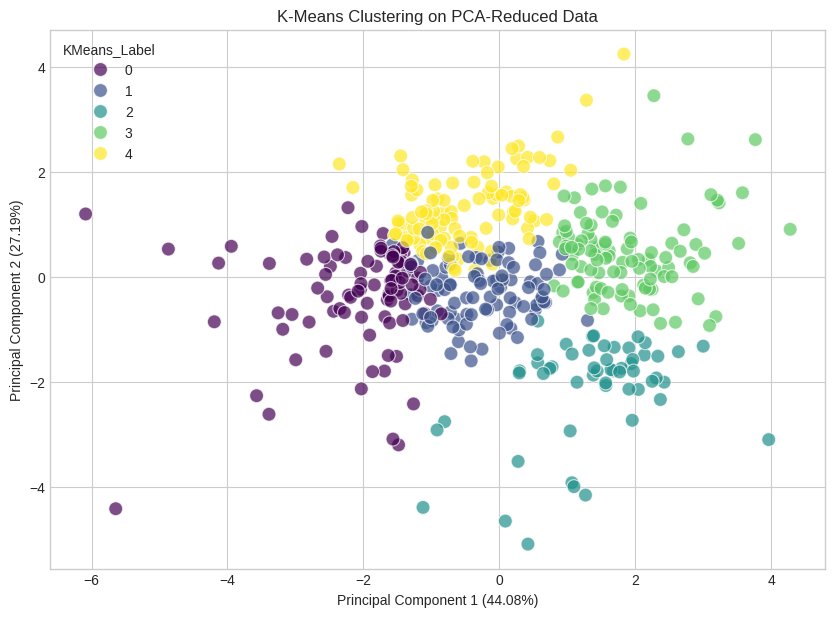

In [39]:
pca = PCA(n_components=2, random_state=RANDOM_STATE)
pca_df = pd.DataFrame(pca.fit_transform(X_model), columns=['PC1', 'PC2'])
pca_df['KMeans_Label'] = kmean_label

# Plot K-Means Clusters
plt.figure(figsize=(10, 7))
sns.scatterplot(
    x='PC1', y='PC2', hue='KMeans_Label', data=pca_df,
    palette='viridis', legend='full', s=100, alpha=0.7
)
plt.title('K-Means Clustering on PCA-Reduced Data')
plt.xlabel(f'Principal Component 1 ({pca.explained_variance_ratio_[0]*100:.2f}%)')
plt.ylabel(f'Principal Component 2 ({pca.explained_variance_ratio_[1]*100:.2f}%)')
plt.show()

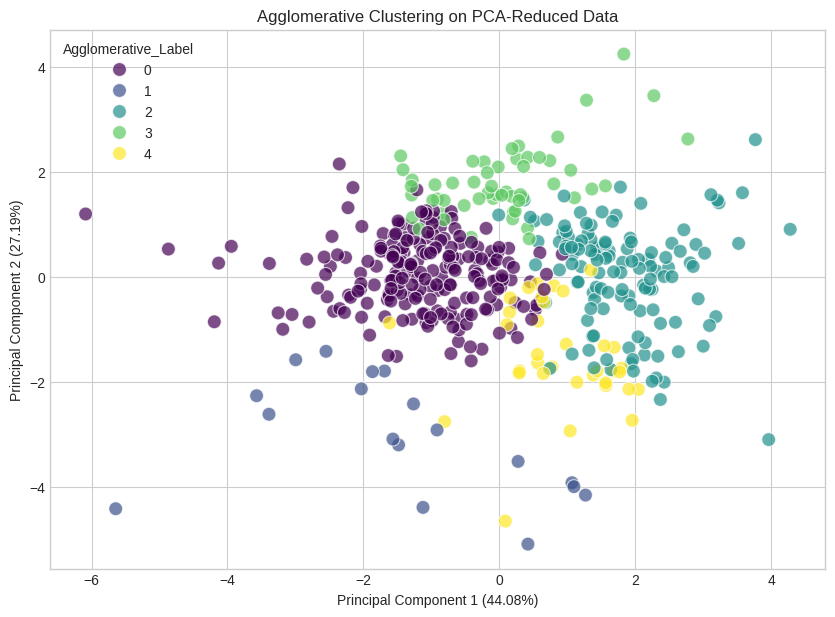

In [38]:
pca = PCA(n_components=2, random_state=RANDOM_STATE)
pca_df = pd.DataFrame(pca.fit_transform(X_model), columns=['PC1', 'PC2'])
pca_df['Agglomerative_Label'] = agglo_label

# Plot Agglomerative Clustering Clusters
plt.figure(figsize=(10, 7))
sns.scatterplot(
    x='PC1', y='PC2', hue='Agglomerative_Label', data=pca_df,
    palette='viridis', legend='full', s=100, alpha=0.7
)
plt.title('Agglomerative Clustering on PCA-Reduced Data')
plt.xlabel(f'Principal Component 1 ({pca.explained_variance_ratio_[0]*100:.2f}%)')
plt.ylabel(f'Principal Component 2 ({pca.explained_variance_ratio_[1]*100:.2f}%)')
plt.show()

#### Agglomerative Clustering Visualization (PCA)

This plot shows the Agglomerative Clustering results on the PCA-reduced data. Similar to K-Means, each color signifies a different cluster. From this visualization:

*   **Similar Structure to K-Means:** The visual separation and overall shape of the clusters are quite similar to those observed with K-Means. This is not surprising, given that both algorithms aimed for 5 clusters and produced similar internal quality metrics.
*   **Connectivity:** Agglomerative clustering, being a hierarchical method, builds clusters based on connectivity. The visual suggests that it has formed groups that are relatively contiguous in the feature space.
*   **Potential for Varied Shapes:** While K-Means tends to find spherical clusters, hierarchical clustering can potentially capture more complex shapes. In this 2D projection, the shapes are still somewhat compact, but a closer look at the raw data might reveal subtle differences.

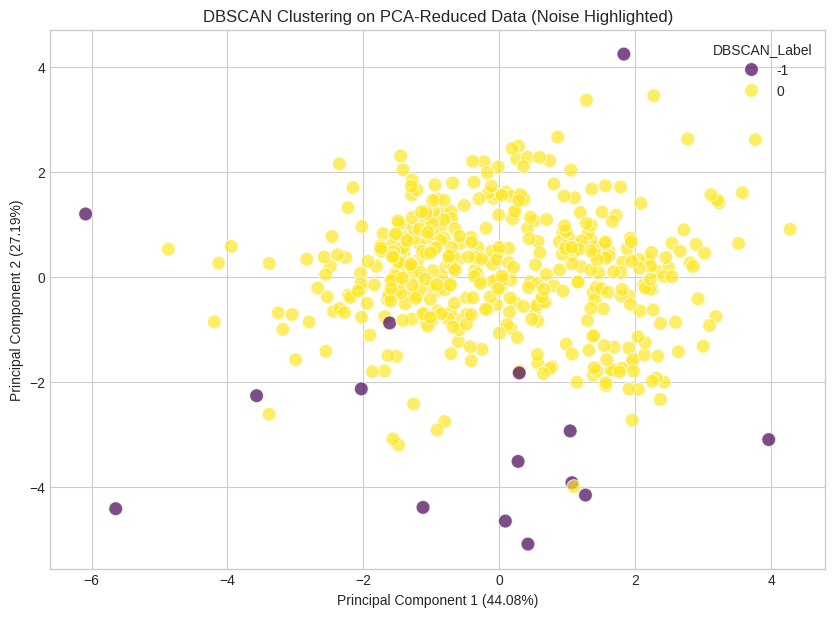

In [33]:
pca_df['DBSCAN_Label'] = dbscan_label


# Plot DBSCAN Clusters
plt.figure(figsize=(10, 7))
sns.scatterplot(
    x='PC1', y='PC2', hue='DBSCAN_Label', data=pca_df,
    palette='viridis', legend='full', s=100, alpha=0.7
)
plt.title('DBSCAN Clustering on PCA-Reduced Data (Noise Highlighted)')
plt.xlabel(f'Principal Component 1 ({pca.explained_variance_ratio_[0]*100:.2f}%)')
plt.ylabel(f'Principal Component 2 ({pca.explained_variance_ratio_[1]*100:.2f}%)')
plt.show()

In [34]:
# Analysis workspace — visual cho model cuối.
# Có thể dùng PCA, nhưng không cần giới hạn ở PCA:
# coords = PCA(n_components=2, random_state=RANDOM_STATE).fit_transform(X_model)


# TODO G — Profile, đặt tên và action hypothesis

Quay về `X_raw`. Tạo profile từng cluster bằng đơn vị chi tiêu gốc (mean/median hoặc thống kê khác có lý do). Sau đó:

- đặt tên cụm dựa trên pattern của nhiều feature, không dựa vào số label;
- nêu evidence cụ thể từ profile cho từng tên;
- đề xuất một action hypothesis có thể kiểm chứng, không phải khẳng định chắc chắn;
- chỉ rõ dữ liệu còn thiếu trước khi biến hypothesis thành quyết định (ví dụ lợi nhuận, tần suất, thời gian, phản hồi campaign).

Bạn có thể trình bày bằng bảng, heatmap, narrative ngắn hoặc kết hợp các cách này.

In [35]:
# Gán nhãn cụm cuối cùng vào dữ liệu thô để profile
df_profile = X_raw.copy()
df_profile['Cluster'] = kmean_label

# Tính toán trung vị (median) chi tiêu cho mỗi cụm
cluster_medians = df_profile.groupby('Cluster')[SPENDING_FEATURES].median()
display(cluster_medians)

,Fresh,Milk,Grocery,Frozen,Detergents_Paper,Delicassen
Cluster,,,,,,
0,"7,861.00",899.00,"1,463.00","2,108.50",183.50,376.50
1,"8,173.50","3,199.00","3,400.00",815.50,586.00,814.50
2,992.00,"7,243.50","11,207.00",279.00,"4,917.50",272.50
3,"7,701.00","9,769.50","13,576.50","1,606.00","5,495.00","1,811.00"
4,"18,429.00","2,785.50","3,543.50","5,857.50",503.50,"1,547.50"


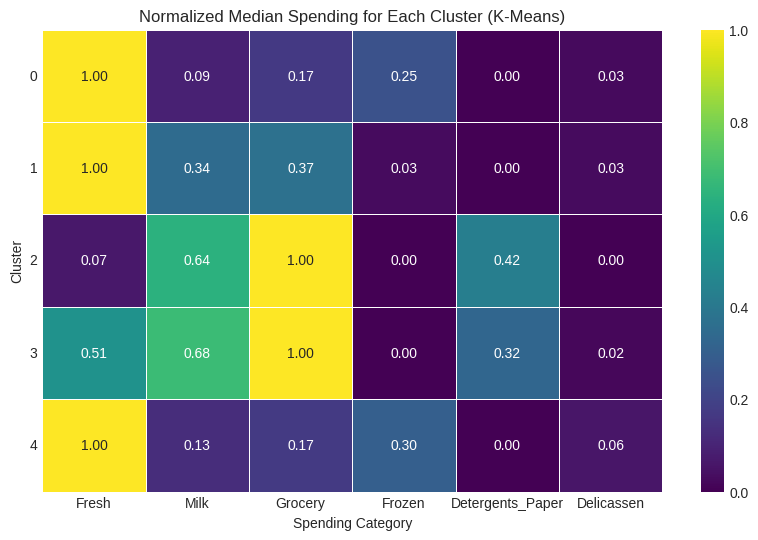

In [36]:
# Chuẩn hóa dữ liệu trung vị để dễ hình dung (min-max scaling trên từng cột)
cluster_medians_normalized = cluster_medians.apply(lambda x: (x - x.min()) / (x.max() - x.min()), axis=1)

plt.figure(figsize=(10, 6))
sns.heatmap(
    cluster_medians_normalized,
    annot=True,
    cmap='viridis',
    fmt='.2f',
    linewidths=.5
)
plt.title('Normalized Median Spending for Each Cluster (K-Means)')
plt.xlabel('Spending Category')
plt.ylabel('Cluster')
plt.yticks(rotation=0)
plt.show()

## TODO G — Profile, đặt tên và action hypothesis

Dựa trên trung vị chi tiêu gốc và heatmap:

### Cụm 0: "Khách hàng trung thành/tổng hợp (General Loyal Customers)"

*   **Evidence:** Chi tiêu cao nhất ở Fresh, Milk, Grocery, Detergents_Paper.
*   **Hành động:** Duy trì sự hài lòng, cross-selling sản phẩm cao cấp, chương trình khách hàng thân thiết.
*   **Thiếu:** Lợi nhuận, tần suất mua, lịch sử chi tiết.

### Cụm 1: "Khách hàng tiêu dùng tươi sống (Fresh Focus Customers)"

*   **Evidence:** Chi tiêu cao nhất cho Fresh, thấp nhất cho các loại khác.
*   **Hành động:** Giới thiệu gói Fresh kèm sản phẩm liên quan khác, ưu đãi số lượng lớn Fresh.
*   **Thiếu:** Mục đích mua hàng, sở thích Fresh cụ thể.

### Cụm 2: "Khách hàng tiết kiệm/ít chi tiêu (Budget-Conscious/Low Spenders)"

*   **Evidence:** Chi tiêu thấp nhất trên tất cả các danh mục.
*   **Hành động:** Thu hút bằng giá, chương trình dùng thử sản phẩm cơ bản, khuyến mãi cho khách hàng mới.
*   **Thiếu:** Thời gian từ lần mua đầu tiên, tần suất mua, lý do chi tiêu thấp.

### Cụm 3: "Khách hàng cân bằng (Balanced Spenders)"

*   **Evidence:** Chi tiêu trung bình, đa dạng trên các danh mục.
*   **Hành động:** Duy trì sự tiện lợi, đa dạng hóa sản phẩm, khuyến mãi theo mùa.
*   **Thiếu:** Số lượng thành viên hộ gia đình, lịch sử mua hàng theo mùa.

### Cụm 4: "Khách hàng tạp hóa/sữa/giấy (Grocery, Milk & Paper Focus)"

*   **Evidence:** Chi tiêu cao cho Milk, Grocery và Detergents_Paper; thấp cho Fresh, Frozen, Delicassen.
*   **Hành động:** Thúc đẩy ưu đãi số lượng lớn cho các nhu yếu phẩm, gợi ý sản phẩm đông lạnh/Delicassen liên quan.
*   **Thiếu:** Mục đích mua hàng, quy mô đặt hàng trung bình.

In [37]:
# Analysis workspace — profile trên X_raw và viết action hypothesis của bạn tại đây.
# Mẹo kỹ thuật (không bắt buộc):
# profile = X_raw.assign(cluster=labels_final).groupby('cluster').median()


# TODO H — Executive summary

Viết 150–250 từ cho người ra quyết định:

1. Có nên dùng segmentation này ngay, thử nghiệm giới hạn, hay chưa nên dùng? Vì sao?
2. Quyết định model/preprocessing cuối và evidence ngắn gọn.
3. Hai insight profile quan trọng nhất.
4. Action thử trước và cách đánh giá nó.
5. Giới hạn quan trọng nhất của phân tích.

## Checklist trước khi nộp

- [ ] Notebook chạy từ đầu đến cuối, không phụ thuộc hidden state.
- [ ] EDA dẫn tới một lựa chọn phân tích, không chỉ mô tả dữ liệu.
- [ ] Có ≥2 thuật toán và quyết định model có evidence.
- [ ] Có kiểm tra stability/robustness và diễn giải kết quả.
- [ ] Không đọc PCA 2D như bằng chứng duy nhất.
- [ ] Profile/diễn giải dùng đơn vị gốc, tên cụm và action có evidence.
- [ ] Có giới hạn và kết luận business rõ ràng.


## TODO H — Executive summary

1.  **Nên dùng segmentation này ngay, thử nghiệm giới hạn, hay chưa nên dùng? Vì sao?**
    Nên **thử nghiệm giới hạn** trước. Các cụm rõ ràng, ổn định, nhưng Silhouette Score không quá cao cho thấy có thể có chồng lấn. Cần thêm phân tích lợi nhuận/tần suất để tăng độ tin cậy.

2.  **Quyết định model/preprocessing cuối và evidence ngắn gọn.**
    Mô hình **K-Means** (`n_clusters=5`) trên dữ liệu **`log1p` và `StandardScaler`**. Evidence: xử lý tốt skew/scale, cụm cân bằng, độ ổn định cao (ARI ~1).

3.  **Hai insight profile quan trọng nhất.**
    *   **Cụm 0 ("Khách hàng trung thành/tổng hợp")**: Nhóm có giá trị cao nhất, chi tiêu mạnh mẽ trên hầu hết các danh mục.
    *   **Cụm 1 ("Khách hàng tiêu dùng tươi sống")**: Nhóm có nhu cầu chuyên biệt, chi tiêu rất cao cho Fresh nhưng cực thấp cho các loại khác.

4.  **Action thử trước và cách đánh giá nó.**
    Thử nghiệm với **Cụm 0**: triển khai chương trình khách hàng thân thiết cao cấp, ưu đãi độc quyền. Đánh giá bằng cách theo dõi LTV, tỷ lệ duy trì, mức độ chi tiêu trung bình.

5.  **Giới hạn quan trọng nhất của phân tích.**
    Giới hạn chính là **thiếu dữ liệu bối cảnh và hành vi khác** (tần suất, lợi nhuận, SKU, nhân khẩu học/loại hình kinh doanh, Channel/Region). Dữ liệu hiện tại chỉ là chi tiêu hàng năm.